# Model-based hypervolume results

Compare the MORBO and qNParEGO adaptations for gravity variance, synchronization, and request heterogeneity. Each algorithm uses **8 initial points, 20 optimization steps, batches of 4, and 2 simulated realizations per candidate**. Initial designs, scenario seeds, scalarization directions, simulator settings, and fixed reference points are matched.

Both implementations adapt the supplied toy notebooks to the same empirical RTS/STR length-scalarized objectives. MORBO uses an adaptive single trust region with joint batch acquisition; qNParEGO uses global search with sequential batch acquisition. These are comparisons of the documented adaptations; see [MORBO](../MORBO/README.md) and [qNParEGO](../qNParEGO/README.md).

Colors distinguish parameter levels. Solid lines with circles show MORBO; dashed lines with squares show qNParEGO. Step 0 is the shared initialization. The fixed normalization is identical between algorithms within each approach.

## Holistic approach: gravity variance

Separate runs for each algorithm compare $\gamma_{\mathrm{grav}}=1$ and $\gamma_{\mathrm{grav}}=5$ under the RTS and STR formulations. Results are loaded from `../MORBO/result_holistic_gravity.pkl`; rerun this notebook after updating the experiment.

The horizontal axis counts **Bayesian optimization steps**. Step **0** is the hypervolume after the initial Sobol design. Each subsequent step fits the surrogate, selects a batch of candidates, evaluates that batch, and records the hypervolume using all observations collected so far. Individual Sobol points and candidates within a batch do not count as separate optimization steps.

Hypervolumes use normalized objectives and a common fixed reference; both figures share the same vertical scale. Only completed optimization steps stored in the result are plotted. The implementation follows the single-trust-region adaptation documented in [MORBO/README.md](../MORBO/README.md).

The matching result in `../qNParEGO/` is overlaid on each figure using the same fixed reference point.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Markdown, display

search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [root / 'MORBO' / 'result_holistic_gravity.pkl' for root in search_roots]
candidates += [root / 'Cosmic Octopi' / 'MORBO' / 'result_holistic_gravity.pkl' for root in search_roots]
result_path = next((path for path in candidates if path.is_file()), None)
if result_path is None:
    raise FileNotFoundError('Run MORBO/script_holistic_gravity.py first.')
with result_path.open('rb') as file:
    gravity_result = pickle.load(file)

setup = gravity_result['setup']
hyperparameters = gravity_result['hyperparameters']
profile = gravity_result['profile'].capitalize()
status = 'complete' if gravity_result['complete'] else 'in progress'
display(Markdown(
    f"**{profile} results ({status}).** "
    f"{hyperparameters['n_initial_points']} initial sequences; "
    f"{hyperparameters['n_iterations']} optimization step(s) "
    f"of {hyperparameters['batch_size']} candidates; "
    f"{setup['n_realizations_per_candidate']} simulated realizations per candidate. "
    f"Common horizon: {setup['holistic']['horizon']} global iterations; "
    f"$M={setup['system_dynamics_parameters']['n_octopi']}$ octopi."
))

def plot_hypervolume(formulation, result):
    setup = result['setup']
    hp = result['hyperparameters']
    approach = 'holistic' if 'holistic' in setup else 'reductionist'
    if 'sweep' in setup:
        parameter = setup['sweep']['parameter']
        condition_values = setup['sweep']['values']
        condition_symbol = setup['sweep']['symbol']
    else:
        parameter = 'gamma_grav'
        condition_values = setup['gravity_variances']
        condition_symbol = 'grav'
    experiment = {'gamma_grav': 'gravity', 'gamma_sync': 'synchronization',
                  'gamma_heter': 'heterogeneity'}[parameter]
    prefix = 'result' if approach == 'holistic' else 'results'
    filename = f'{prefix}_{approach}_{experiment}.pkl'
    roots = (Path.cwd(), *Path.cwd().parents)
    paths = [root / 'qNParEGO' / filename for root in roots]
    paths += [root / 'Cosmic Octopi' / 'qNParEGO' / filename for root in roots]
    comparison_path = next((path for path in paths if path.is_file()), None)
    if comparison_path is None:
        raise FileNotFoundError(f'Run qNParEGO/script_{approach}_{experiment}.py first.')
    with comparison_path.open('rb') as file:
        comparison = pickle.load(file)
    for key in ('reference_costs', 'system_dynamics_parameters', 'hyper_parameters',
                'fitness_margin_bounds', 'policy_shapes', 'simulated_rewards',
                'n_realizations_per_candidate', 'gravity_mean', 'ou_substeps', approach):
        if comparison['setup'][key] != setup[key]:
            raise ValueError(f'MORBO and qNParEGO have different {key}.')
    for key in ('n_initial_points', 'n_iterations', 'batch_size',
                'hypervolume_directions', 'direction_endpoint_epsilon'):
        if comparison['hyperparameters'][key] != hp[key]:
            raise ValueError(f'MORBO and qNParEGO have different {key}.')
    if comparison['setup']['sweep']['values'] != condition_values:
        raise ValueError('The algorithms use different sweep values.')
    records = [('MORBO', result), ('qNParEGO', comparison)]
    all_hypervolumes = []
    for _, record in records:
        for run in record['runs'].values():
            if not run['hypervolume_history']:
                continue
            steps = np.arange(len(run['hypervolume_history']))
            expected = hp['n_initial_points'] + steps * hp['batch_size']
            np.testing.assert_array_equal(run['evaluation_counts'], expected)
            if len(steps) != len(run['direction_angle_history']) + 1:
                raise ValueError('Hypervolume history does not match completed steps.')
            all_hypervolumes.extend(run['hypervolume_history'])
    if not all_hypervolumes:
        raise ValueError('No completed checkpoints are available.')
    y_min, y_max = min(all_hypervolumes), max(all_hypervolumes)
    padding = max((y_max - y_min) * 0.08, 0.0001)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    fig, ax = plt.subplots(figsize=(6, 5))
    plotted_steps = []
    for algorithm, record in records:
        for index, level in enumerate(condition_values):
            selected = [run for run in record['runs'].values()
                        if run['formulation'] == formulation
                        and run.get('sweep_value', run.get('gravity_variance')) == level
                        and run['hypervolume_history']]
            if not selected:
                continue
            if len(selected) != 1:
                raise ValueError('More than one run matches this algorithm/condition.')
            run = selected[0]
            values = np.asarray(run['hypervolume_history'])
            steps = np.arange(len(values))
            ax.plot(
                steps, values, color=colors[index % len(colors)],
                linestyle='-' if algorithm == 'MORBO' else '--',
                marker='o' if algorithm == 'MORBO' else 's',
                linewidth=2, markersize=4,
                label=algorithm + r', $\gamma_{\mathrm{' + condition_symbol + '}} = ' + f'{level:g}' + '$',
            )
            plotted_steps.extend(steps)
    ax.set_xlabel('Optimization step', fontsize=14)
    ax.set_ylabel('Normalized hypervolume', fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    unique_steps = sorted(set(plotted_steps))
    if len(unique_steps) <= 12:
        ax.set_xticks(unique_steps)
    else:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.set_ylim(y_min - padding, y_max + padding)
    ax.grid(False)
    ax.legend(fontsize=10)
    fig.tight_layout()
    plt.show()


**Full results (complete).** 8 initial sequences; 20 optimization step(s) of 4 candidates; 2 simulated realizations per candidate. Common horizon: 100 global iterations; $M=40$ octopi.

### RTS

Average the objective realizations, then apply length scalarization.

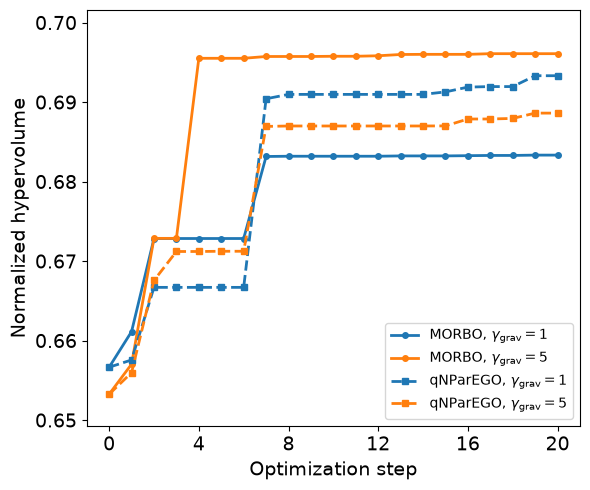

In [2]:
plot_hypervolume('RTS', gravity_result)

### STR

Apply length scalarization to each realization, then average.

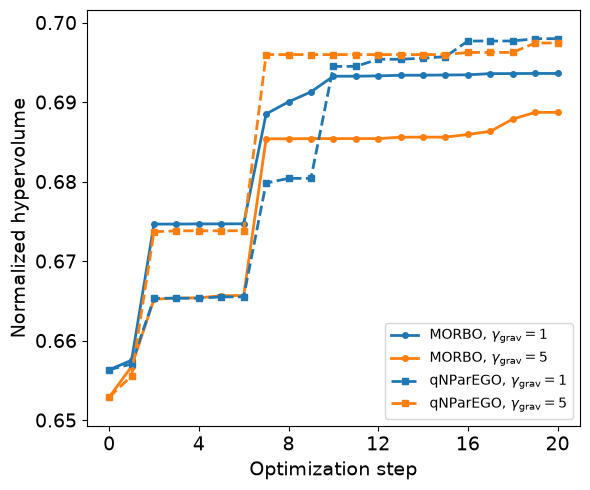

In [3]:
plot_hypervolume('STR', gravity_result)

## Reductionist approach: gravity variance (Cheetah)

These independent RTS and STR runs optimize a sequence of 50 Cheetah fitness margins, counting only Cheetah requests, overhead, and instability. They compare $\gamma_{\mathrm{grav}}=1$ and $\gamma_{\mathrm{grav}}=5$ with the same 40-octopus simulator settings and optimizer budget as the holistic experiment.

Results come from `../MORBO/results_reductionist_gravity.pkl`, generated by `../MORBO/script_reductionist_gravity.py`. Step **0** is the initial Sobol design; each later point records a completed optimization batch.

The fixed reference is **(90,497.578125 KiB, 85)**. Its overhead coordinate is 1.01 times the maximum possible uploads over 50 Cheetah requests; this replaces the paper's 4,000 KiB value for the current simulator. Both reductionist figures share a vertical scale and reference. Their normalized hypervolumes use a different reference from the holistic figures.

The matching result in `../qNParEGO/` is overlaid on each figure using the same fixed reference point.

In [4]:
search_roots = (Path.cwd(), *Path.cwd().parents)
reductionist_candidates = [
    root / 'MORBO' / 'results_reductionist_gravity.pkl' for root in search_roots
]
reductionist_candidates += [
    root / 'Cosmic Octopi' / 'MORBO' / 'results_reductionist_gravity.pkl'
    for root in search_roots
]
reductionist_result_path = next(
    (path for path in reductionist_candidates if path.is_file()), None
)
if reductionist_result_path is None:
    raise FileNotFoundError('Run MORBO/script_reductionist_gravity.py first.')
with reductionist_result_path.open('rb') as file:
    reductionist_gravity_result = pickle.load(file)

reductionist_setup = reductionist_gravity_result['setup']
reductionist_hp = reductionist_gravity_result['hyperparameters']
reductionist_profile = reductionist_gravity_result['profile'].capitalize()
reductionist_status = 'complete' if reductionist_gravity_result['complete'] else 'in progress'
display(Markdown(
    f"**{reductionist_profile} results ({reductionist_status}).** "
    f"{reductionist_hp['n_initial_points']} initial sequences; "
    f"{reductionist_hp['n_iterations']} optimization steps "
    f"of {reductionist_hp['batch_size']} candidates; "
    f"{reductionist_setup['n_realizations_per_candidate']} simulated realizations per candidate. "
    f"Class: {reductionist_setup['reductionist']['class_name']}; "
    f"horizon: {reductionist_setup['reductionist']['horizon']} class requests; "
    f"$M={reductionist_setup['system_dynamics_parameters']['n_octopi']}$ octopi."
))

**Full results (complete).** 8 initial sequences; 20 optimization steps of 4 candidates; 2 simulated realizations per candidate. Class: Cheetah; horizon: 50 class requests; $M=40$ octopi.

### RTS (Cheetah)

Average the Cheetah objective realizations, then apply length scalarization.

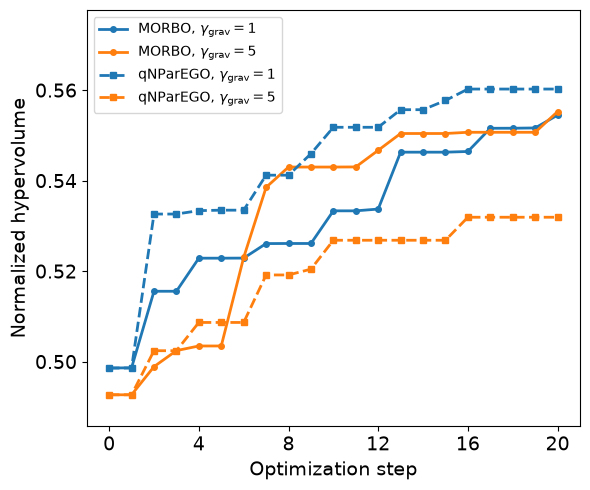

In [5]:
plot_hypervolume('RTS', reductionist_gravity_result)

### STR (Cheetah)

Apply length scalarization to each Cheetah realization, then average.

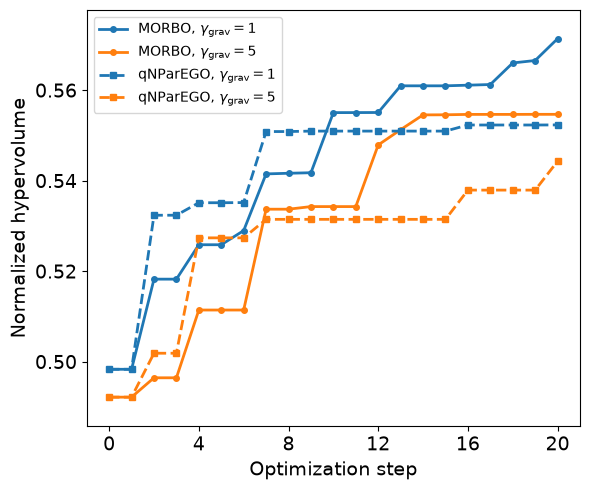

In [6]:
plot_hypervolume('STR', reductionist_gravity_result)

## Holistic approach: synchronization

Compare $\gamma_{\mathrm{sync}}=1$ (synchronous) and $\gamma_{\mathrm{sync}}=0.8$, fixing $\gamma_{\mathrm{grav}}=0.1$ and $\gamma_{\mathrm{heter}}=0.5$. The experiment uses 40 octopi, simulated rewards, and a common horizon of 100 global iterations.

`../MORBO/script_holistic_synchronization.py` reads its own setup and writes `../MORBO/result_holistic_synchronization.pkl`. The optimizer settings, margin bounds, and fixed reference **(2,200,000 KiB, 310)** match the holistic gravity experiment. Step 0 is initialization; later points are completed Bayesian optimization steps. Both synchronization figures share a vertical scale.

The matching result in `../qNParEGO/` is overlaid on each figure using the same fixed reference point.

In [7]:
def load_morbo_result(filename):
    search_roots = (Path.cwd(), *Path.cwd().parents)
    candidates = [root / 'MORBO' / filename for root in search_roots]
    candidates += [root / 'Cosmic Octopi' / 'MORBO' / filename for root in search_roots]
    path = next((path for path in candidates if path.is_file()), None)
    if path is None:
        raise FileNotFoundError(f'Run the MORBO experiment that produces {filename} first.')
    with path.open('rb') as file:
        return pickle.load(file)


def show_morbo_summary(result):
    config = result['setup']
    hp = result['hyperparameters']
    approach = result['approach']
    status = 'complete' if result['complete'] else 'in progress'
    horizon = config[approach]['horizon']
    scope = ('global iterations' if approach == 'holistic'
             else f"{config[approach]['class_name']} requests")
    display(Markdown(
        f"**{result['profile'].capitalize()} results ({status}).** "
        f"{hp['n_initial_points']} initial sequences; {hp['n_iterations']} optimization steps "
        f"of {hp['batch_size']} candidates; "
        f"{config['n_realizations_per_candidate']} simulated realizations per candidate. "
        f"Horizon: {horizon} {scope}; "
        f"$M={config['system_dynamics_parameters']['n_octopi']}$ octopi."
    ))


holistic_synchronization_result = load_morbo_result('result_holistic_synchronization.pkl')
show_morbo_summary(holistic_synchronization_result)


**Full results (complete).** 8 initial sequences; 20 optimization steps of 4 candidates; 2 simulated realizations per candidate. Horizon: 100 global iterations; $M=40$ octopi.

### RTS

Average the holistic objective realizations, then apply length scalarization.

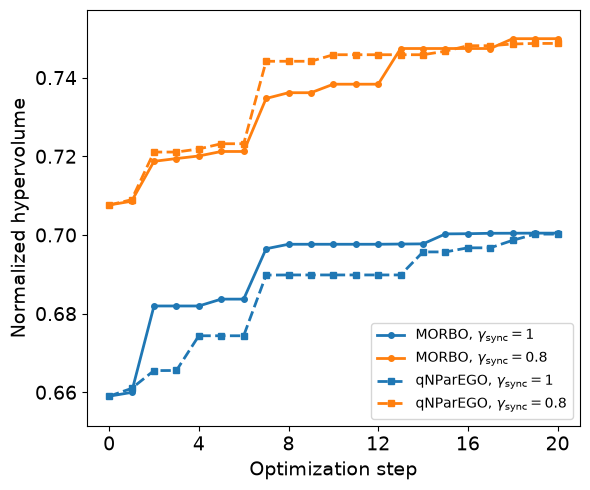

In [8]:
plot_hypervolume('RTS', holistic_synchronization_result)

### STR

Apply length scalarization to each holistic realization, then average.

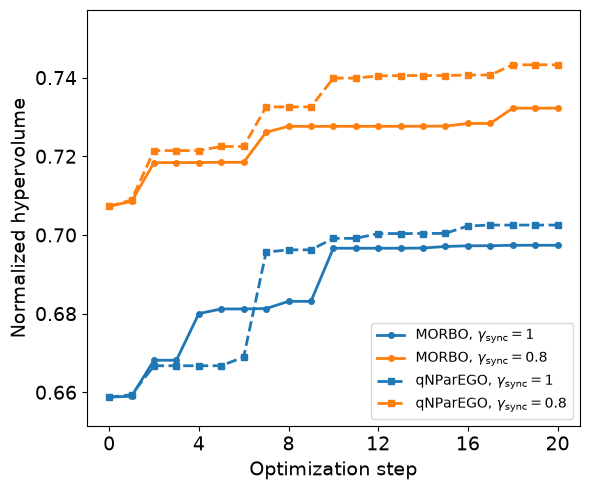

In [9]:
plot_hypervolume('STR', holistic_synchronization_result)

## Reductionist approach: synchronization (Cheetah)

Compare the same synchronization levels, $\gamma_{\mathrm{sync}}=1$ and $0.8$, with $\gamma_{\mathrm{grav}}=0.1$ and $\gamma_{\mathrm{heter}}=0.5$. Only Cheetah overhead and instability are counted, over 50 Cheetah requests with 40 octopi.

`../MORBO/script_reductionist_synchronization.py` writes `../MORBO/results_reductionist_synchronization.pkl`. The optimizer settings and fixed simulator reference **(90,497.578125 KiB, 85)** match the Cheetah gravity experiment. Both synchronization levels and formulations use this fixed reference. The two figures share a vertical scale and show completed optimization steps, with initialization at step 0.

The matching result in `../qNParEGO/` is overlaid on each figure using the same fixed reference point.

In [10]:
reductionist_synchronization_result = load_morbo_result('results_reductionist_synchronization.pkl')
show_morbo_summary(reductionist_synchronization_result)

**Full results (complete).** 8 initial sequences; 20 optimization steps of 4 candidates; 2 simulated realizations per candidate. Horizon: 50 Cheetah requests; $M=40$ octopi.

### RTS (Cheetah)

Average the Cheetah objective realizations, then apply length scalarization.

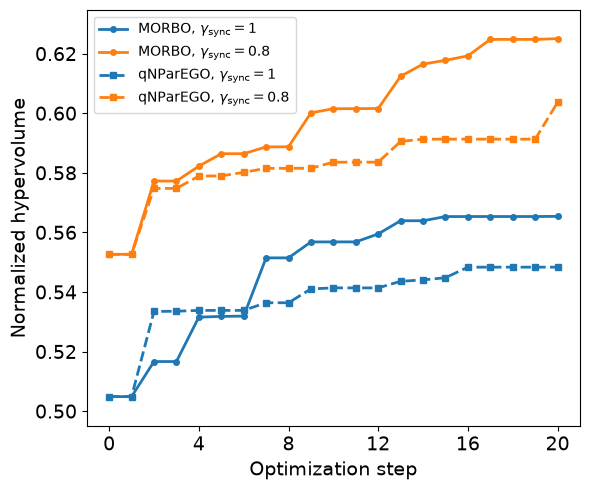

In [11]:
plot_hypervolume('RTS', reductionist_synchronization_result)

### STR (Cheetah)

Apply length scalarization to each Cheetah realization, then average.

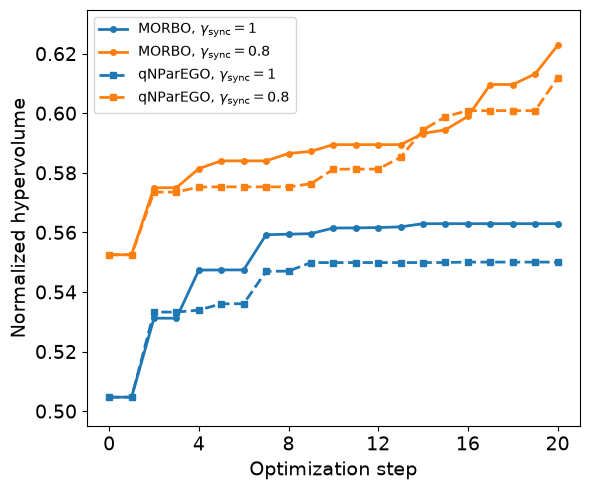

In [12]:
plot_hypervolume('STR', reductionist_synchronization_result)

## Holistic approach: request heterogeneity

Compare $\gamma_{\mathrm{heter}}=0.1$ and $\gamma_{\mathrm{heter}}=0.8$, fixing $\gamma_{\mathrm{sync}}=1$ and $\gamma_{\mathrm{grav}}=0.1$, as in Section 7.4.3 of the paper. The experiment uses 40 octopi, simulated rewards, and a common horizon of 100 global iterations.

`../MORBO/script_holistic_heterogeneity.py` reads its own setup and writes `../MORBO/result_holistic_heterogeneity.pkl`. The shared optimizer settings, margin bounds, and fixed reference **(2,200,000 KiB, 310)** match the preceding holistic experiments. Step 0 is initialization; the next 20 points are completed Bayesian optimization steps. Both request heterogeneity figures share a vertical scale.

The matching result in `../qNParEGO/` is overlaid on each figure using the same fixed reference point.

In [13]:
holistic_heterogeneity_result = load_morbo_result('result_holistic_heterogeneity.pkl')
show_morbo_summary(holistic_heterogeneity_result)

**Full results (complete).** 8 initial sequences; 20 optimization steps of 4 candidates; 2 simulated realizations per candidate. Horizon: 100 global iterations; $M=40$ octopi.

### RTS

Average the holistic objective realizations, then apply length scalarization.

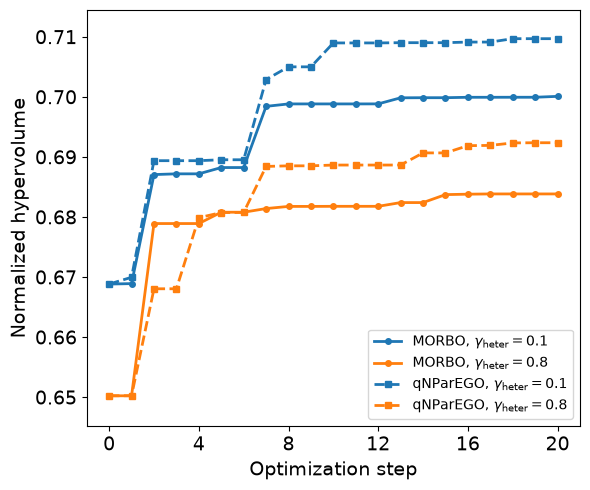

In [14]:
plot_hypervolume('RTS', holistic_heterogeneity_result)

### STR

Apply length scalarization to each holistic realization, then average.

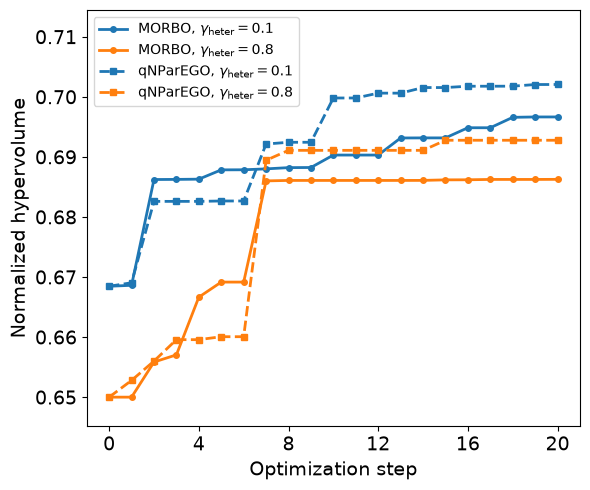

In [15]:
plot_hypervolume('STR', holistic_heterogeneity_result)

## Reductionist approach: request heterogeneity (Cheetah)

Compare $\gamma_{\mathrm{heter}}=0.1$ and $\gamma_{\mathrm{heter}}=0.8$, with $\gamma_{\mathrm{sync}}=1$ and $\gamma_{\mathrm{grav}}=0.1$. Only Cheetah overhead and instability are counted, over 50 Cheetah requests with 40 octopi.

`../MORBO/script_reductionist_heterogeneity.py` writes `../MORBO/results_reductionist_heterogeneity.pkl`. The optimizer settings and fixed simulator reference **(90,497.578125 KiB, 85)** match the preceding Cheetah experiments. Both heterogeneity levels and formulations use this fixed reference. The two figures share a vertical scale and show completed optimization steps, with initialization at step 0.

The matching result in `../qNParEGO/` is overlaid on each figure using the same fixed reference point.

In [16]:
reductionist_heterogeneity_result = load_morbo_result('results_reductionist_heterogeneity.pkl')
show_morbo_summary(reductionist_heterogeneity_result)

**Full results (complete).** 8 initial sequences; 20 optimization steps of 4 candidates; 2 simulated realizations per candidate. Horizon: 50 Cheetah requests; $M=40$ octopi.

### RTS (Cheetah)

Average the Cheetah objective realizations, then apply length scalarization.

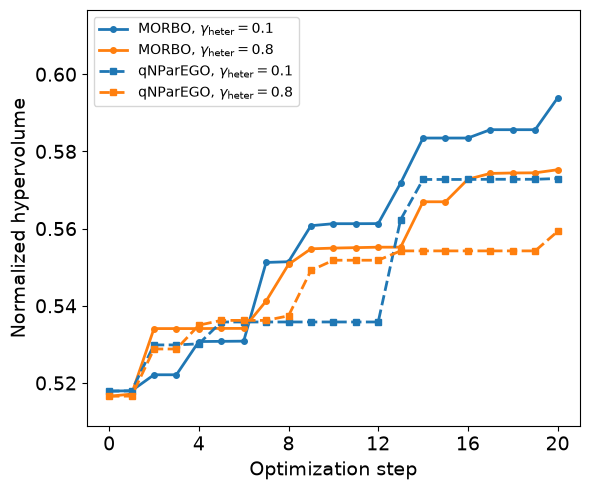

In [17]:
plot_hypervolume('RTS', reductionist_heterogeneity_result)

### STR (Cheetah)

Apply length scalarization to each Cheetah realization, then average.

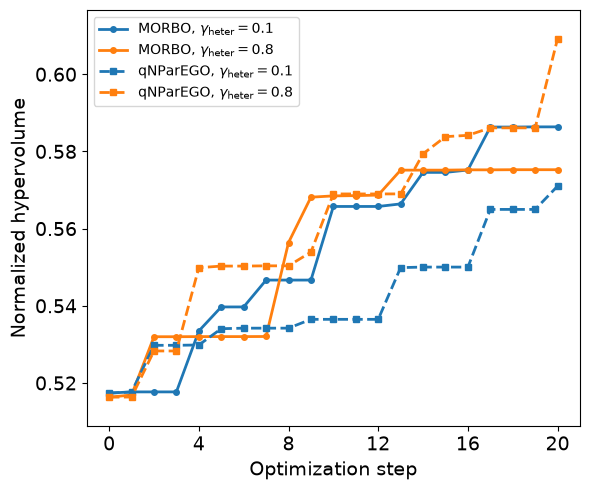

In [18]:
plot_hypervolume('STR', reductionist_heterogeneity_result)